# Training a DDPM on emoji images

Trains the UNet from `unet.py` to predict the noise added by a linear-beta
forward process. Start by **overfitting a single image** (`SINGLE_IMAGE = True`)
to confirm the loop works, then flip the flag to train on all 193.

The diffusion math is written inline here so it is easy to poke at. `diffusion.py`
holds the same math as an importable `Diffusion` class (and `train.py` runs this
loop headless) — if you change it here, change it there too.

## Config

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

from dataloader import EmojiDataset
from unet import UNet

# --- diffusion ---
T = 1000              # number of timesteps
BETA_START = 1e-4
BETA_END = 0.02

# --- training ---
BATCH_SIZE = 8
LR = 2e-4
STEPS = 2000
LOG_EVERY = 100

# --- data ---
SINGLE_IMAGE = True   # False -> train on the whole dataset
IMAGE_INDEX = 0       # which image to overfit

# --- sampling ---
START_T = 300         # < T noises the real image to START_T and denoises from there
N_SAMPLES = 4         # how many images to generate from pure noise

SEED = 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(SEED)
print(f"device: {DEVICE}")

device: cuda


## Data

In [2]:
dataset = EmojiDataset()
print(f"{len(dataset)} images")

x0_single = dataset[IMAGE_INDEX].unsqueeze(0).to(DEVICE)   # (1, 3, 64, 64) in [-1, 1]
print(f"single-image target: {dataset.paths[IMAGE_INDEX].name}  {tuple(x0_single.shape)}")

193 images
single-image target: 1F193.png  (1, 3, 64, 64)


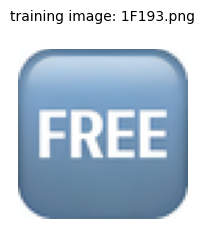

In [3]:
def show(x, titles=None, title=None):
    """Display a (C,H,W) or (B,C,H,W) tensor in [-1, 1] as images."""
    x = x.detach().cpu().clamp(-1, 1)
    if x.dim() == 3:
        x = x[None]

    fig, axes = plt.subplots(1, len(x), figsize=(2.0 * len(x), 2.3))
    for i, (ax, img) in enumerate(zip(np.atleast_1d(axes), x)):
        ax.imshow(((img + 1) / 2).permute(1, 2, 0).numpy())
        ax.axis("off")
        if titles is not None:
            ax.set_title(titles[i], fontsize=9, color="#555")
    if title:
        fig.suptitle(title, fontsize=10)
    plt.tight_layout()
    plt.show()


show(x0_single, title=f"training image: {dataset.paths[IMAGE_INDEX].name}")

## Diffusion schedule

`betas` is a linear ramp; everything else is derived from it.
`alphas_cumprod[t]` is the fraction of the *original image* still present at step `t`.

In [4]:
betas = torch.linspace(BETA_START, BETA_END, T, device=DEVICE)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

print(f"alphas_cumprod[0]   = {alphas_cumprod[0]:.6f}   -> sqrt = {alphas_cumprod[0].sqrt():.4f}")
print(f"alphas_cumprod[-1]  = {alphas_cumprod[-1]:.6e}   -> sqrt = {alphas_cumprod[-1].sqrt():.4f}")

alphas_cumprod[0]   = 0.999900   -> sqrt = 0.9999
alphas_cumprod[-1]  = 4.035829e-05   -> sqrt = 0.0064


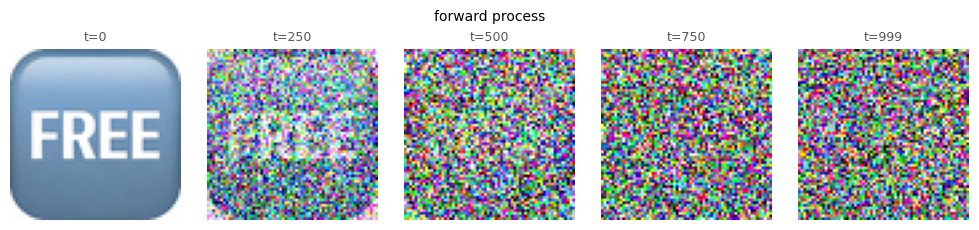

In [5]:
def q_sample(x0, t, noise):
    """Forward process: x_t = sqrt(acp_t) * x0 + sqrt(1 - acp_t) * noise."""
    acp = alphas_cumprod[t].view(-1, 1, 1, 1)
    return acp.sqrt() * x0 + (1 - acp).sqrt() * noise


# Sanity check: the image should be pure static by t = T.
ts = [0, 250, 500, 750, T - 1]
noised = torch.stack([
    q_sample(x0_single, torch.tensor([t], device=DEVICE), torch.randn_like(x0_single))[0]
    for t in ts
])
show(noised, titles=[f"t={t}" for t in ts], title="forward process")

## Batch source

In [6]:
if SINGLE_IMAGE:
    def get_batch():
        return x0_single.repeat(BATCH_SIZE, 1, 1, 1)

    print(f"overfitting {dataset.paths[IMAGE_INDEX].name}")
else:
    from torch.utils.data import DataLoader

    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    _it = iter(loader)

    def get_batch():
        global _it
        try:
            batch = next(_it)
        except StopIteration:
            _it = iter(loader)
            batch = next(_it)
        return batch.to(DEVICE)

    print(f"training on all {len(dataset)} images")

print(f"batch: {tuple(get_batch().shape)}")

overfitting 1F193.png
batch: (8, 3, 64, 64)


## Model and optimizer

In [7]:
model = UNet().to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=LR)

print(f"params: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")

params: 15.7M


## Training loop

Each step: draw a random `t` per sample, noise the batch to that `t`, and ask the
model to predict the noise it was given. Loss is the MSE between the two.
Re-run this cell to keep training from where it left off.

In [8]:
losses = []
window = []

for step in range(1, STEPS + 1):
    x0 = get_batch()
    t = torch.randint(0, T, (x0.shape[0],), device=DEVICE)
    noise = torch.randn_like(x0)

    x_t = q_sample(x0, t, noise)
    loss = F.mse_loss(model(x_t, t), noise)

    opt.zero_grad()
    loss.backward()
    opt.step()

    losses.append(loss.item())
    window.append(loss.item())
    if step % LOG_EVERY == 0:
        print(f"step {step:5d} | loss {sum(window) / len(window):.4f}")
        window.clear()

step   100 | loss 0.1468
step   200 | loss 0.0542
step   300 | loss 0.0360
step   400 | loss 0.0210
step   500 | loss 0.0183
step   600 | loss 0.0155
step   700 | loss 0.0099
step   800 | loss 0.0104
step   900 | loss 0.0072
step  1000 | loss 0.0146
step  1100 | loss 0.0057
step  1200 | loss 0.0066
step  1300 | loss 0.0059
step  1400 | loss 0.0046
step  1500 | loss 0.0110
step  1600 | loss 0.0054
step  1700 | loss 0.0087
step  1800 | loss 0.0089
step  1900 | loss 0.0074
step  2000 | loss 0.0074


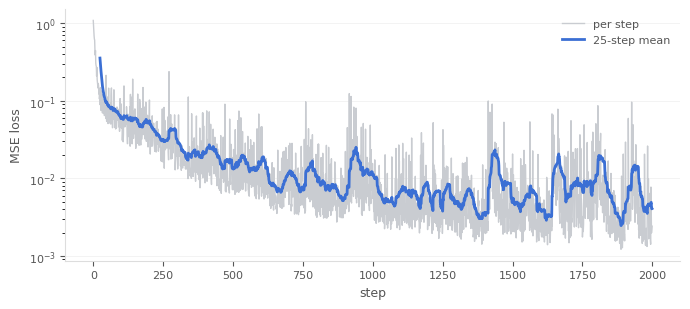

In [9]:
def smooth(values, k=25):
    """Running mean, returned with the x positions it lines up with."""
    if len(values) < k:
        return np.arange(len(values)), np.array(values)
    y = np.convolve(values, np.ones(k) / k, mode="valid")
    return np.arange(len(y)) + k - 1, y


fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(losses, linewidth=1, color="#c9ccd1", label="per step")
ax.plot(*smooth(losses), linewidth=2, color="#3b6fd4", label="25-step mean")

ax.set_yscale("log")
ax.set_xlabel("step", fontsize=9, color="#555")
ax.set_ylabel("MSE loss", fontsize=9, color="#555")
ax.tick_params(labelsize=8, colors="#555")
ax.grid(axis="y", linewidth=0.5, color="#eee")
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color("#ddd")
ax.legend(fontsize=8, frameon=False, labelcolor="#555")

plt.tight_layout()
plt.show()

## Inference — reverse diffusion

Walk `t` from `start_t - 1` down to `0`, at each step subtracting the predicted
noise and adding back a little fresh noise (except at the final step).

- `x0=None` starts from pure noise — full generation, the hard case.
- passing `x0` noises that real image up to `start_t` and denoises from there —
  a much gentler test, useful right after overfitting.

In [10]:
@torch.no_grad()
def sample(model, n=1, start_t=None, x0=None):
    """Reverse diffusion from start_t down to 0. Returns (n, 3, 64, 64) in [-1, 1]."""
    model.eval()
    start_t = start_t or T

    if x0 is None:
        x = torch.randn(n, 3, 64, 64, device=DEVICE)
    else:
        t = torch.full((x0.shape[0],), start_t - 1, device=DEVICE)
        x = q_sample(x0, t, torch.randn_like(x0))

    for i in reversed(range(start_t)):
        t = torch.full((x.shape[0],), i, device=DEVICE)
        eps = model(x, t)

        mean = (x - betas[i] / (1 - alphas_cumprod[i]).sqrt() * eps) / alphas[i].sqrt()

        if i > 0:
            # sigma_t^2 = beta_t, the "fixedlarge" choice from the DDPM paper.
            x = mean + betas[i].sqrt() * torch.randn_like(x)
        else:
            x = mean

    model.train()
    return x

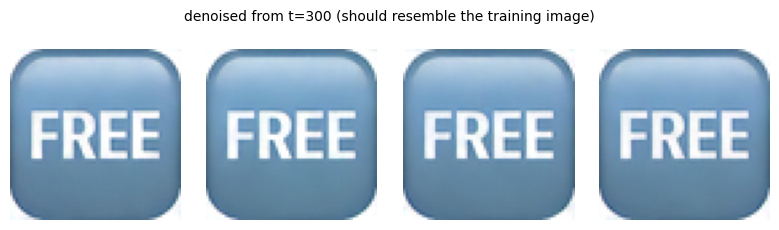

In [11]:
# Easier check: noise the real image to START_T, then denoise it back.
partial = sample(model, start_t=START_T, x0=x0_single.repeat(N_SAMPLES, 1, 1, 1))
show(partial, title=f"denoised from t={START_T} (should resemble the training image)")

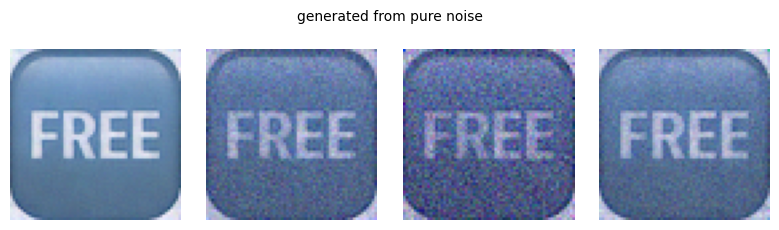

In [12]:
# Harder check: full generation from pure noise.
generated = sample(model, n=N_SAMPLES, start_t=T)
show(generated, title="generated from pure noise")

## Save

In [ ]:
torch.save(model.state_dict(), "ckpt.pt")
print("saved ckpt.pt")